In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import CategoricalDtype
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Complaints2.csv")
df.head(5)

,CASE_ID,OFFER_NAME,CUSTOMER_TYPE,CUSTOMER_GROUP,CURRENT_STATUS,ESCALATION_FLAG,OPEN_DATE,OPEN_USER,CLOSE_DATE,CLOSE_GROUP,CLOSE_USER,AGE_BRACKET,ACTUAL_COMPLAINT,OPEN_GR,COMPLAINT_TYPE,PRODUCT,CASE,Customer Satisfication Score
0,CAS-1060890-L3D6Q6,FTTH Home,CBU,FTTH Home,Resolved,Yes,19.06.2022 06:07,DANA,21.06.2022 13:41,F&I_BO,DANA,2.0,Actual Complaint,CBU / EBU - personal view,Technical,Internet,Technical complaint,0.929588
1,CAS-388567-W4B9Q3,Bitstream Home,CBU,FTTH Home,Resolved,Yes,04.04.2022 14:11,TCRMService,05.04.2022 12:13,Mobile_BO,ENNAS,1.0,Not Actual Complaint,System Administrator,Commercial,Mobile,Commercial claim,0.966339
2,CAS-1494939-L9F0X7,Bitstream Home,CBU,Wanadoo-ADSL-Res,Resolved,No,03.08.2022 03:20,MOUTAZ,03.08.2022 03:20,CYC_COMMERCAIL_TEAM,MOUTAZ,1.0,User Not Filled,CBU - CC 1st Layer A,Technical,Internet,Technical complaint,0.523956
3,CAS-1059985-K3Y9F7,FTTH Home,CBU,FTTH Home,Resolved,No,18.06.2022 20:38,MOATH,18.06.2022 20:38,NaN,MOATH,1.0,User Not Filled,NaN,Technical,Internet,Technical complaint,0.978215
4,CAS-1239942-Y1S2F5,FTTH Home,CBU,FTTH Home,Resolved,No,06.07.2022 01:22,IBRAHIM,06.07.2022 01:22,CYC_COMMERCAIL_TEAM,IBRAHIM,1.0,User Not Filled,CBU - CC 1st Layer A,Technical,Internet,Technical complaint,0.944564


# Preproccessing

In [ ]:
# To know the number of records and features in the dataset
df.shape

(10415, 18)

In [ ]:
# To show the statistical information of the numeric features
# In order to find any unlogic value
df.describe()

,AGE_BRACKET,Customer Satisfication Score
count,10296.000000,10415.000000
mean,1.503302,0.517737
std,2.978144,0.292215
min,1.000000,0.000069
25%,1.000000,0.261822
50%,1.000000,0.531625
75%,1.000000,0.774104
max,116.000000,0.999966


In [ ]:
#Count the number of null values in the dataset
df.isnull().sum()

CASE_ID                            0
OFFER_NAME                         0
CUSTOMER_TYPE                      0
CUSTOMER_GROUP                     0
CURRENT_STATUS                     0
ESCALATION_FLAG                    0
OPEN_DATE                          0
OPEN_USER                          0
CLOSE_DATE                       119
CLOSE_GROUP                     4890
CLOSE_USER                       516
AGE_BRACKET                      119
ACTUAL_COMPLAINT                   0
OPEN_GR                         4561
COMPLAINT_TYPE                     0
PRODUCT                            0
CASE                               0
Customer Satisfication Score       0
dtype: int64

In [ ]:
#count the number of duplicated rows in the dataset
df.duplicated().sum()

0

In [ ]:
df.dtypes

CASE_ID                          object
OFFER_NAME                       object
CUSTOMER_TYPE                    object
CUSTOMER_GROUP                   object
CURRENT_STATUS                   object
ESCALATION_FLAG                  object
OPEN_DATE                        object
OPEN_USER                        object
CLOSE_DATE                       object
CLOSE_GROUP                      object
CLOSE_USER                       object
AGE_BRACKET                     float64
ACTUAL_COMPLAINT                 object
OPEN_GR                          object
COMPLAINT_TYPE                   object
PRODUCT                          object
CASE                             object
Customer Satisfication Score    float64
dtype: object

In [ ]:
#To know what is the values inside this feature and the counts of them
df['CURRENT_STATUS'].value_counts()

Resolved    10292
Active        123
Name: CURRENT_STATUS, dtype: int64

In [ ]:
#Contengency table to know where is exactly the null values occures in CLOSE_USER fearture
Table=pd.crosstab(index = df['CLOSE_USER'].isnull(), columns=df['CURRENT_STATUS'], margins=True)
Table

CURRENT_STATUS,Active,Resolved,All
CLOSE_USER,,,
False,3,9896,9899
True,120,396,516
All,123,10292,10415


In [ ]:
#fill the null values in CLOSE_USER feature when it's exist with the active value in CURRENT_STATUS feature
df['CLOSE_USER']=np.where(df['CURRENT_STATUS'] == 'Active', 'Still Active', df['CLOSE_USER'])

In [ ]:
df['CLOSE_USER'].isnull().sum()

396

In [ ]:
#fill null values in this feature with unknown
df['CLOSE_USER'].fillna('Unknown',inplace=True)

In [ ]:
# Convert 'OPEN_DATE' and 'CLOSE_DATE' columns to datetime format, handling errors by coercing to NaT
df['OPEN_DATE'] = pd.to_datetime(df['OPEN_DATE'], errors='coerce')
df['CLOSE_DATE'] = pd.to_datetime(df['CLOSE_DATE'], errors='coerce')

#standardize the date format to '%Y-%m-%d %H:%M:%S'
# Convert 'OPEN_DATE' and 'CLOSE_DATE' to the desired format
df['OPEN_DATE'] = df['OPEN_DATE'].dt.strftime('%Y-%m-%d %H:%M:%S')
df['CLOSE_DATE'] = df['CLOSE_DATE'].dt.strftime('%Y-%m-%d %H:%M:%S')


In [ ]:
df['OPEN_DATE'] = pd.to_datetime(df['OPEN_DATE'], errors='coerce')
df['CLOSE_DATE'] = pd.to_datetime(df['CLOSE_DATE'], errors='coerce')

In [ ]:
df[['OPEN_DATE','CLOSE_DATE']].isnull().sum()

OPEN_DATE      19
CLOSE_DATE    138
dtype: int64

In [ ]:
df['OPEN_GR'].fillna('Unknown',inplace=True)
df['CLOSE_GROUP'].fillna('Unknown',inplace=True)

In [ ]:
#To convert from categorical data with ordinal relationship into numeric data
le = LabelEncoder()
df['CURRENT_STATUS_ENCODED'] = le.fit_transform(df['CURRENT_STATUS'])

In [ ]:
df.corr()

<ipython-input-46-2f6f6606aa2c>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,AGE_BRACKET,Customer Satisfication Score,CURRENT_STATUS_ENCODED
AGE_BRACKET,1.000000,0.005222,0.003332
Customer Satisfication Score,0.005222,1.000000,-0.000632
CURRENT_STATUS_ENCODED,0.003332,-0.000632,1.000000


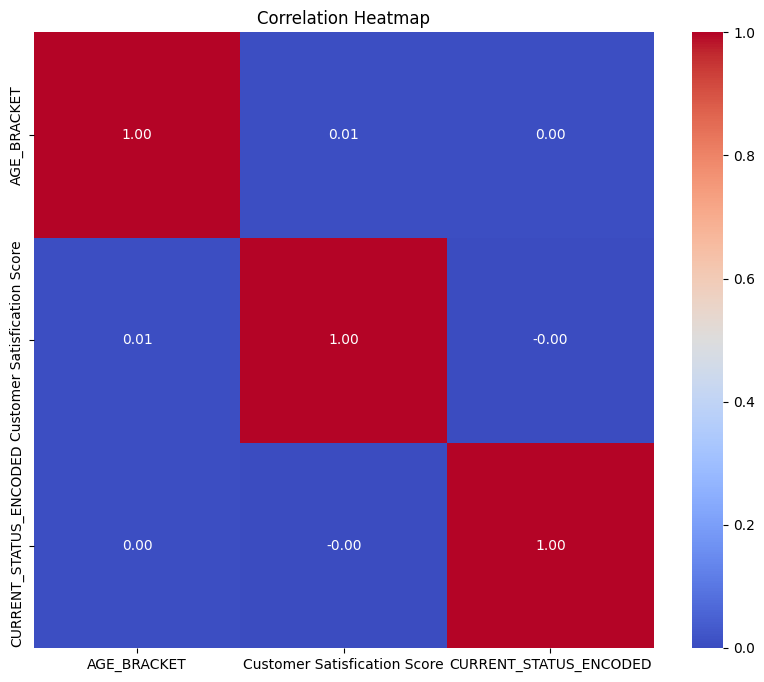

In [ ]:
# Select numeric columns from the DataFrame
numeric_cols = df.select_dtypes(include='number')

# Calculate the correlation matrix
correlation_matrix = numeric_cols.corr()

# Create a heatmap using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
#Drop this feature from the dataframe after taking the benefit from it
df.drop('CURRENT_STATUS_ENCODED',axis=1,inplace=True)

In [ ]:
#After applying label encoding on current status feature it gives negative relationship with the target fearture
#so the decision is to drop the null values from close_Date and AGE_BRACKET features
df.dropna(subset=['AGE_BRACKET'],inplace=True)

In [ ]:
#By back to Excel these nulls aren't logical values, and after applying the heatmap and it gives negative relationship,
#so the decision is to drop them
df.dropna(subset=['OPEN_DATE','CLOSE_DATE'],inplace=True)

In [ ]:
df.isnull().sum()

CASE_ID                         0
OFFER_NAME                      0
CUSTOMER_TYPE                   0
CUSTOMER_GROUP                  0
CURRENT_STATUS                  0
ESCALATION_FLAG                 0
OPEN_DATE                       0
OPEN_USER                       0
CLOSE_DATE                      0
CLOSE_GROUP                     0
CLOSE_USER                      0
AGE_BRACKET                     0
ACTUAL_COMPLAINT                0
OPEN_GR                         0
COMPLAINT_TYPE                  0
PRODUCT                         0
CASE                            0
Customer Satisfication Score    0
dtype: int64

# Descriptive Analysis& Visualization


In [ ]:
print('Median: ',df['Customer Satisfication Score'].median())

Median:  0.531541029


In [ ]:
#To know what is the values inside this feature and the counts of them
df['ESCALATION_FLAG'].value_counts()

No     6950
Yes    3327
Name: ESCALATION_FLAG, dtype: int64

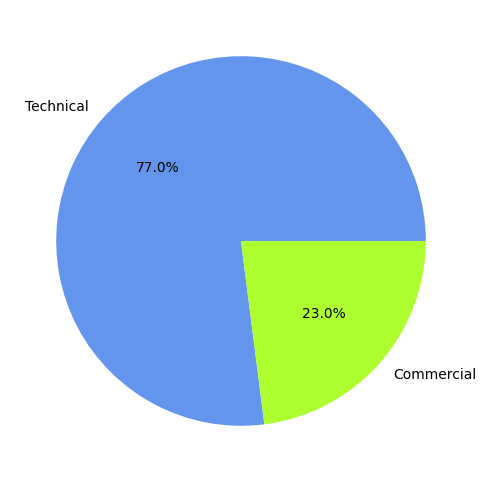

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(df['COMPLAINT_TYPE'].value_counts(), labels=df['COMPLAINT_TYPE'].unique(), colors= ('cornflowerblue', 'greenyellow'), autopct='%1.1f%%')
plt.show()

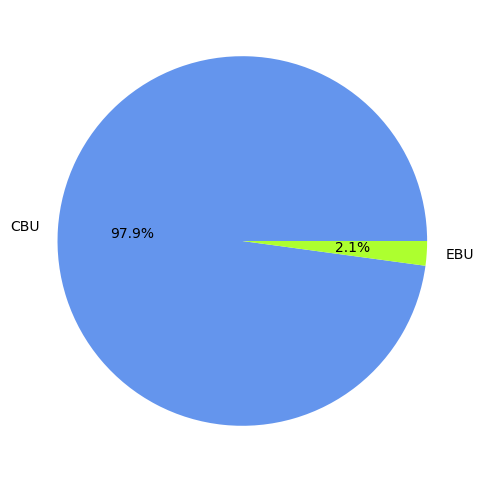

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(df['CUSTOMER_TYPE'].value_counts(), labels=df['CUSTOMER_TYPE'].unique(), colors= ('cornflowerblue', 'greenyellow'), autopct='%1.1f%%')
plt.show()

In [ ]:
#Contengency table to know which one of the complaint types are usually escalated
Table=pd.crosstab(index = df['PRODUCT'], columns=df['ESCALATION_FLAG'], margins=True)
Table

ESCALATION_FLAG,No,Yes,All
PRODUCT,,,
Internet,5781,1426,7207
Mobile,1169,1901,3070
All,6950,3327,10277


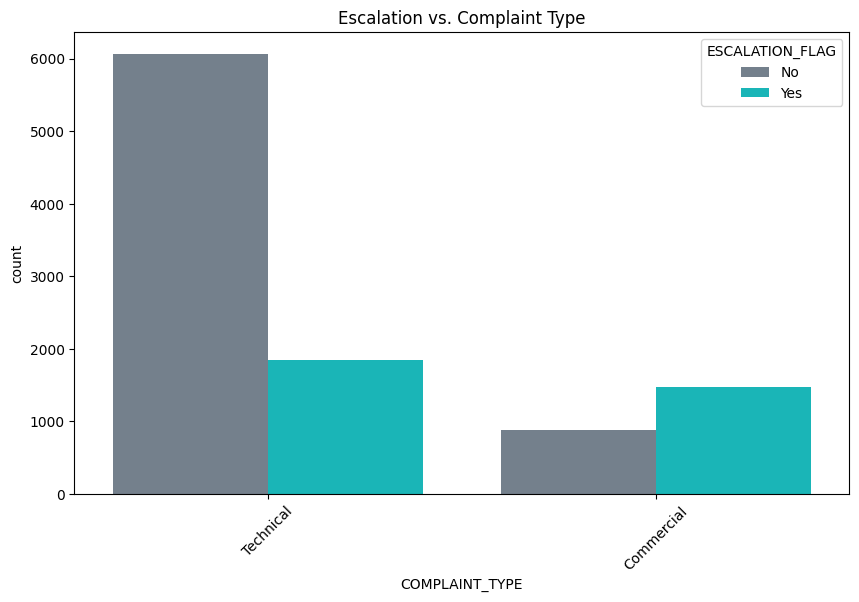

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='COMPLAINT_TYPE', hue='ESCALATION_FLAG', palette=('slategrey', 'darkturquoise'), data=df, hue_order=['No', 'Yes'])
plt.title('Escalation vs. Complaint Type')
plt.xticks(rotation=45)
plt.show()


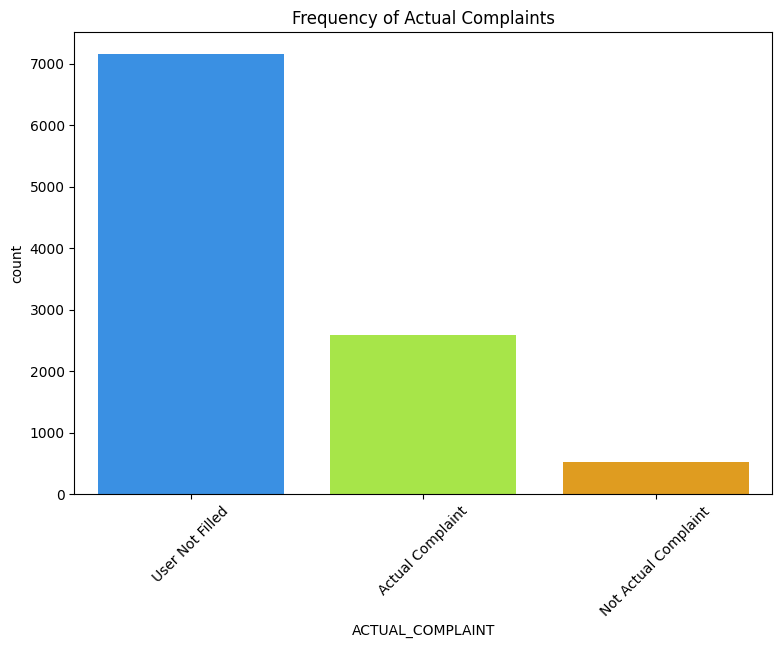

In [ ]:
plt.figure(figsize=(9, 6))
sns.countplot(x='ACTUAL_COMPLAINT', palette=['dodgerblue','greenyellow','orange'], data=df, order=df['ACTUAL_COMPLAINT'].value_counts().index)
plt.title('Frequency of Actual Complaints')
plt.xticks(rotation=45)
plt.show()

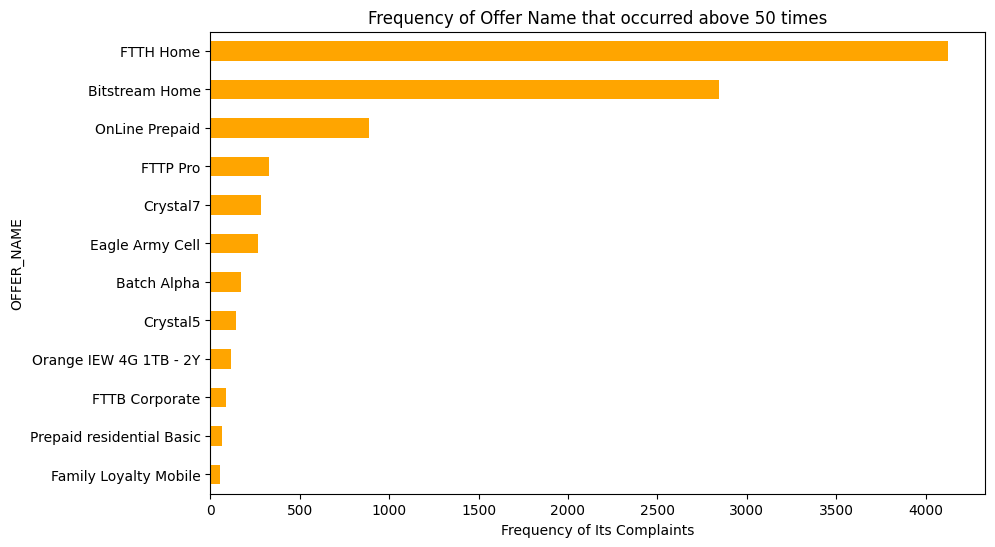

In [ ]:
# Calculate the frequency of each unique offer
offer_frequency = df['OFFER_NAME'].value_counts().sort_values()

# Set a threshold for the minimum frequency
frequency_threshold = 50  # Adjust the threshold as needed

# Filter out offers with frequency below the threshold
filtered_offer_frequency = offer_frequency[offer_frequency >= frequency_threshold]

# Plot a horizontally oriented bar chart
plt.figure(figsize=(10, 6))
filtered_offer_frequency.plot(kind='barh', color='orange')

plt.title('Frequency of Offer Name that occurred above 50 times')
plt.xlabel('Frequency of Its Complaints')
plt.ylabel('OFFER_NAME')
plt.show()


<ipython-input-76-74b4422a71ae>:11: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  filtered_age_by_offer = pd.Series()
<ipython-input-76-74b4422a71ae>:12: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  for offer, avg_age in average_age_by_offer.iteritems():


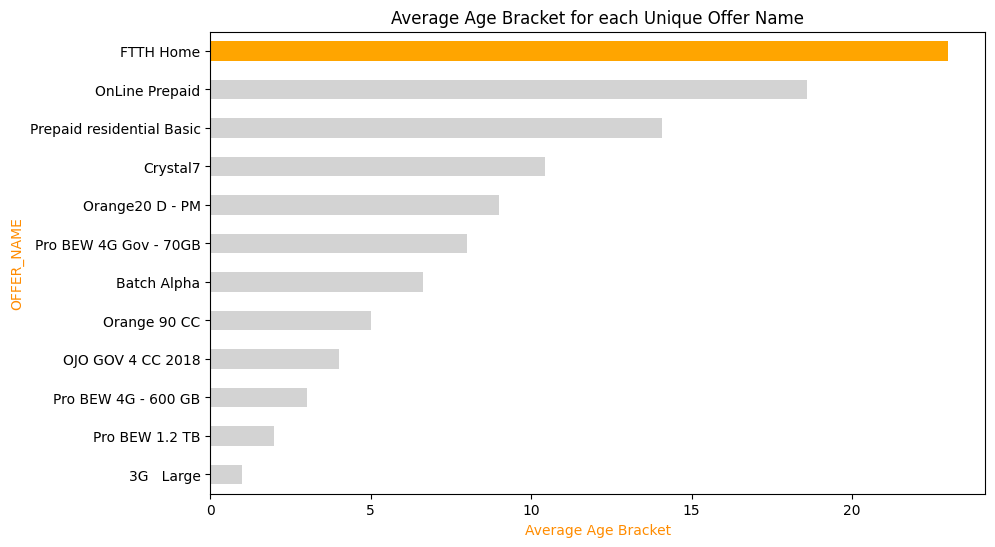

In [ ]:
# Remove duplicates based on 'AGE_BRACKET' and 'OFFER_NAME', keeping the first encountered offer
unique_data = df.drop_duplicates(subset=['AGE_BRACKET', 'OFFER_NAME'], keep='first')

# Calculate the average age bracket for each unique offer
average_age_by_offer = unique_data.groupby('OFFER_NAME')['AGE_BRACKET'].mean().sort_values()

# Set a threshold for the minimum age bracket difference between offers
age_bracket_threshold = 1.0

# Filter out offers with similar age brackets
filtered_age_by_offer = pd.Series()
for offer, avg_age in average_age_by_offer.iteritems():
    if not any(abs(avg_age - filtered_avg_age) < age_bracket_threshold for filtered_avg_age in filtered_age_by_offer):
        filtered_age_by_offer[offer] = avg_age

# Plot a horizontally oriented bar chart
plt.figure(figsize=(10, 6))
filtered_age_by_offer.plot(kind='barh', color= (['lightgray'] * (len(filtered_age_by_offer) - 1) + ['orange']))

plt.title('Average Age Bracket for each Unique Offer Name')
plt.xlabel('Average Age Bracket', color='darkorange')
plt.ylabel('OFFER_NAME', color='darkorange')
plt.show()

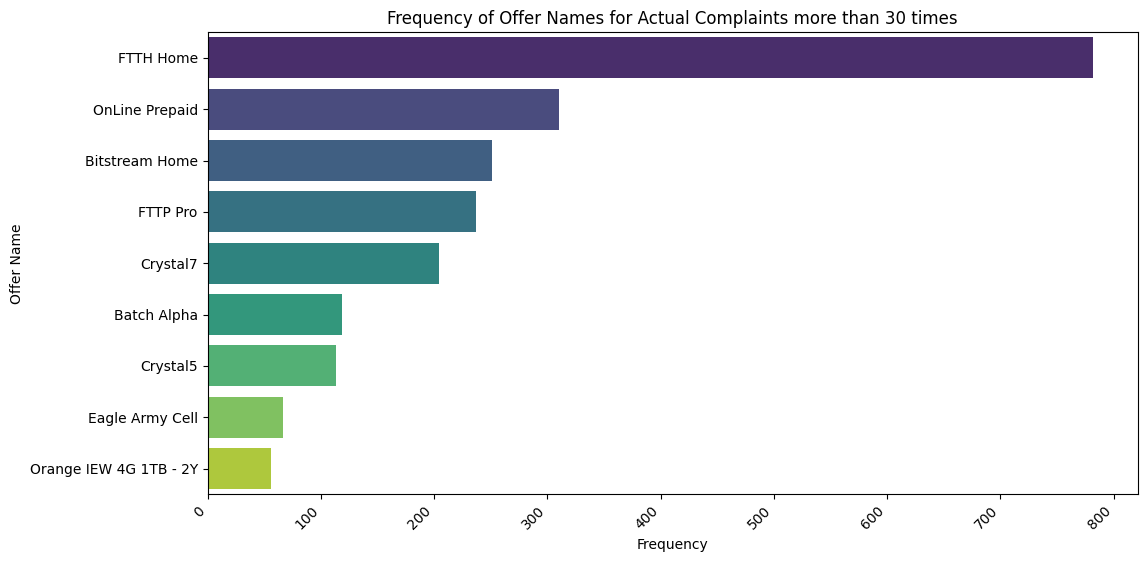

In [ ]:
# Assuming your DataFrame is named 'df' and contains the necessary columns

# Filter the DataFrame for actual complaints
actual_complaints_df = df[df['ACTUAL_COMPLAINT'] == 'Actual Complaint']

# Count the frequency of each offer name
offer_name_counts = actual_complaints_df['OFFER_NAME'].value_counts()

# Filter for offers with frequency greater than 30
filtered_offer_names = offer_name_counts[offer_name_counts > 30]

# Plot the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(y=filtered_offer_names.index, x=filtered_offer_names.values, palette='viridis')
plt.title('Frequency of Offer Names for Actual Complaints more than 30 times')
plt.xlabel('Frequency')
plt.ylabel('Offer Name')
plt.xticks(rotation=45, ha='right')
plt.show()


In [ ]:
#Contengency table to know where is exactly the null values occures in CLOSE_USER fearture
Table=pd.crosstab( columns=  df['ACTUAL_COMPLAINT'], index = df['ESCALATION_FLAG'], margins=True)
Table

ACTUAL_COMPLAINT,Actual Complaint,Not Actual Complaint,User Not Filled,All
ESCALATION_FLAG,,,,
No,5,2,6943,6950
Yes,2591,523,213,3327
All,2596,525,7156,10277


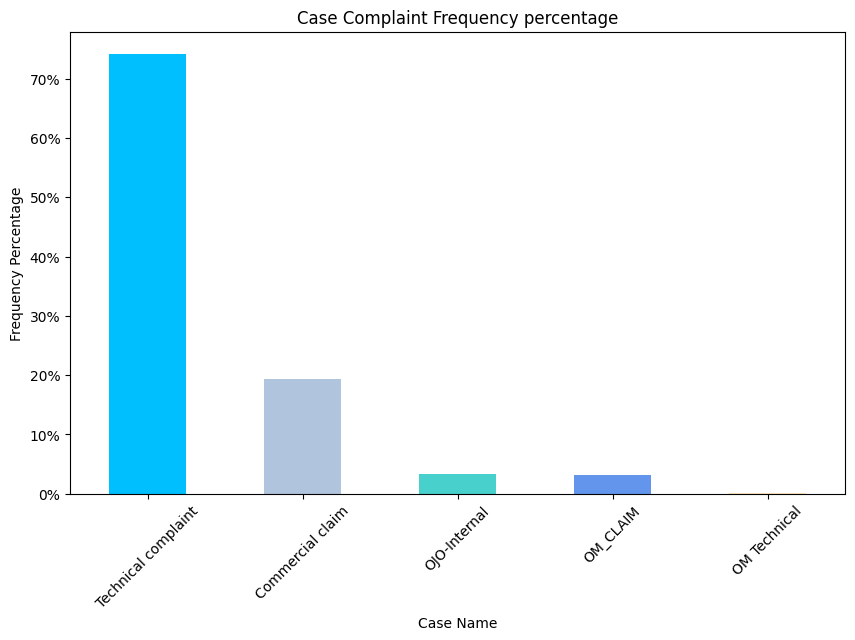

In [ ]:
import matplotlib.ticker as mtick

# Calculate the percentage frequency for each case
plt.figure(figsize=(10, 6))
custom_colors = ['deepskyblue', 'lightsteelblue', 'mediumturquoise', 'cornflowerblue', 'moccasin']

# Calculate the percentage frequencies
percentage_frequencies = (df['CASE'].value_counts() / len(df['CASE'])) * 100

# Plot the bar chart with percentage frequencies
percentage_frequencies.plot(kind='bar', color=custom_colors)

plt.title('Case Complaint Frequency percentage')
plt.xlabel('Case Name')
plt.ylabel('Frequency Percentage')
plt.xticks(rotation=45)

# Set y-axis ticks as percentages
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())

plt.show()

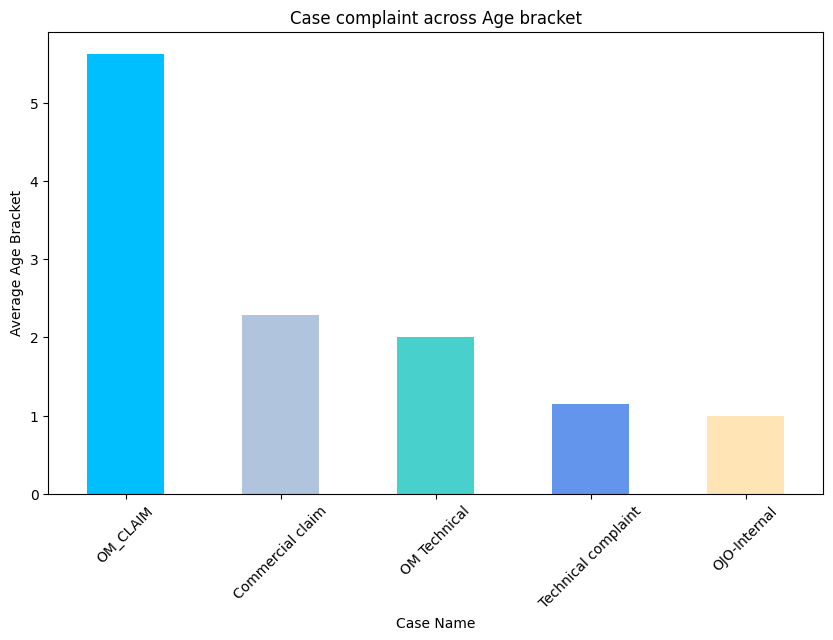

In [ ]:
# Calculate the average age bracket for each complaint type
average_age_by_offer = df.groupby('CASE')['AGE_BRACKET'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
custom_colors = ['deepskyblue', 'lightsteelblue', 'mediumturquoise', 'cornflowerblue', 'moccasin']
average_age_by_offer.plot(kind='bar', color=custom_colors)
plt.title('Case complaint across Age bracket')
plt.xlabel('Case Name')
plt.ylabel('Average Age Bracket')
plt.xticks(rotation=45)
plt.show()

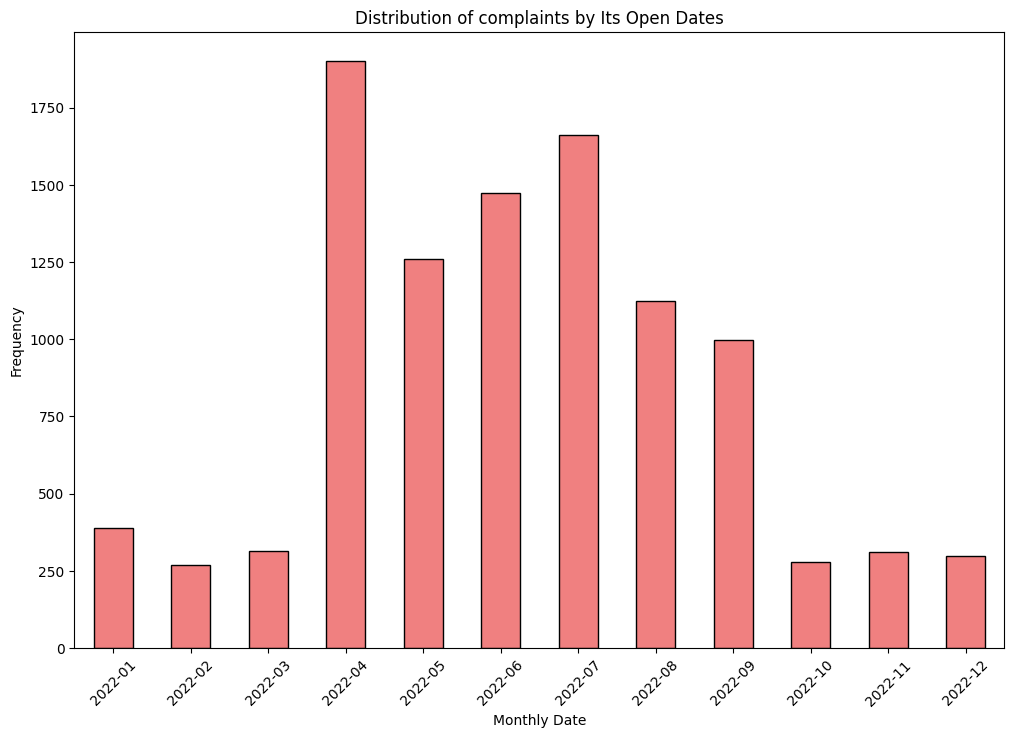

In [ ]:
df['MonthYear'] = df['OPEN_DATE'].dt.to_period('M')

# Count the occurrences of each unique 'MonthYear'
month_year_counts = df['MonthYear'].value_counts().sort_index()

# Plot the histogram
plt.figure(figsize=(12, 8))
month_year_counts.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Distribution of complaints by Its Open Dates')
plt.xlabel('Monthly Date')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


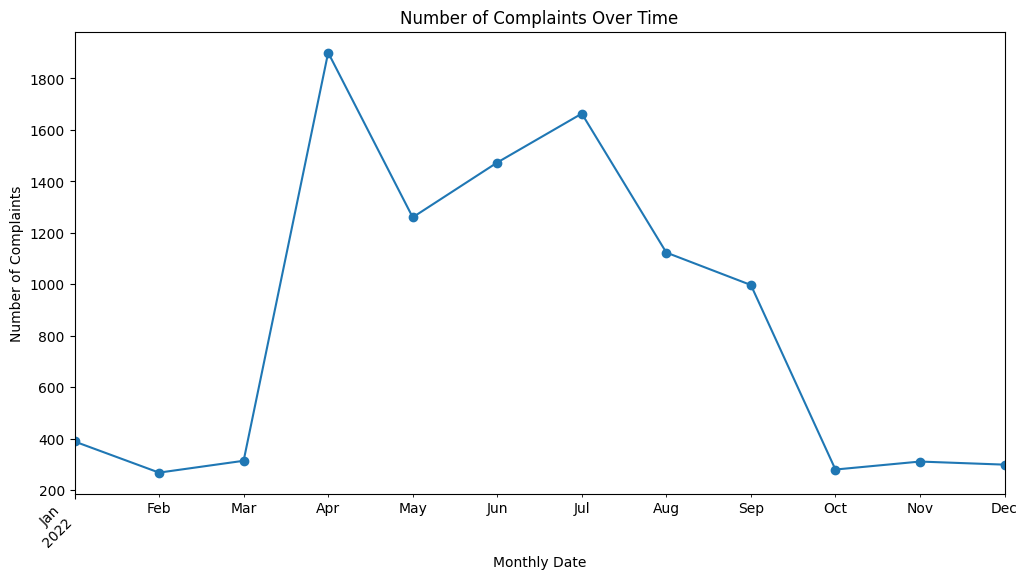

In [ ]:
# Plot the line chart
plt.figure(figsize=(12, 6))
month_year_counts.plot(kind='line', marker='o')
plt.title('Number of Complaints Over Time')
plt.xlabel('Monthly Date')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45, ha='right')
plt.show()

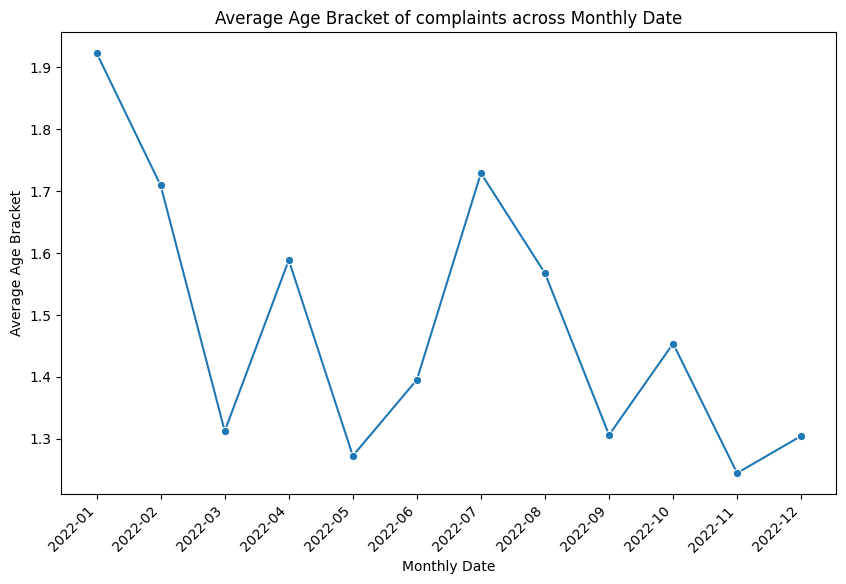

In [ ]:
# Calculate the mean 'AGE_BRACKET' for each month
average_age_by_month = df.groupby('MonthYear')['AGE_BRACKET'].mean()

# Plot a line plot
plt.figure(figsize=(10, 6))
sns.lineplot(x=average_age_by_month.index.astype(str), y=average_age_by_month.values, marker='o')
plt.title('Average Age Bracket of complaints across Monthly Date')
plt.xlabel('Monthly Date')
plt.ylabel('Average Age Bracket')
plt.xticks(rotation=45, ha='right')
plt.show()

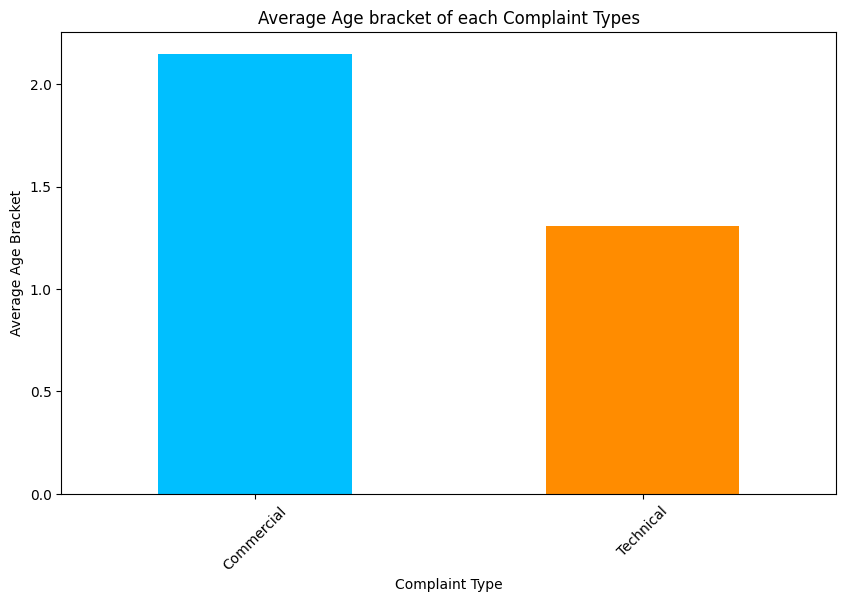

In [ ]:
# Calculate the average age bracket for each complaint type
average_age_by_offer = df.groupby('COMPLAINT_TYPE')['AGE_BRACKET'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
custom_colors = ['deepskyblue', 'darkorange']
average_age_by_offer.plot(kind='bar', color=custom_colors)
plt.title('Average Age bracket of each Complaint Types')
plt.xlabel('Complaint Type')
plt.ylabel('Average Age Bracket')
plt.xticks(rotation=45)
plt.show()

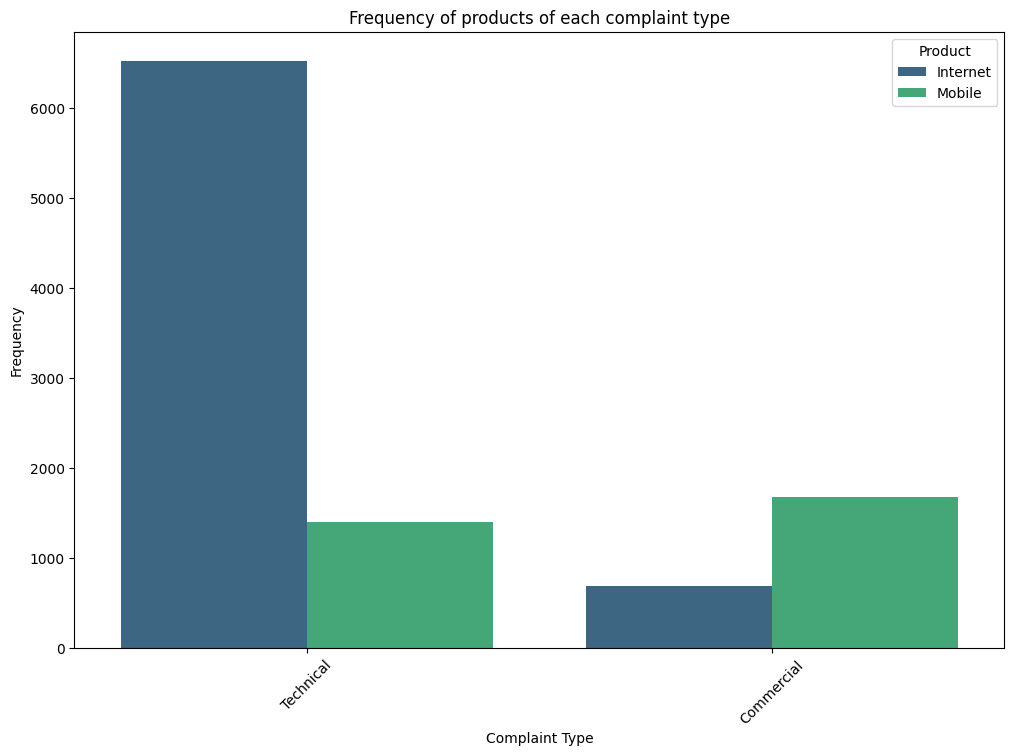

In [ ]:
plt.figure(figsize=(12, 8))
sns.countplot(x='COMPLAINT_TYPE', hue='PRODUCT', data=df, palette='viridis')
plt.title('Frequency of products of each complaint type')
plt.xlabel('Complaint Type')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.legend(title='Product', loc='upper right')
plt.show()

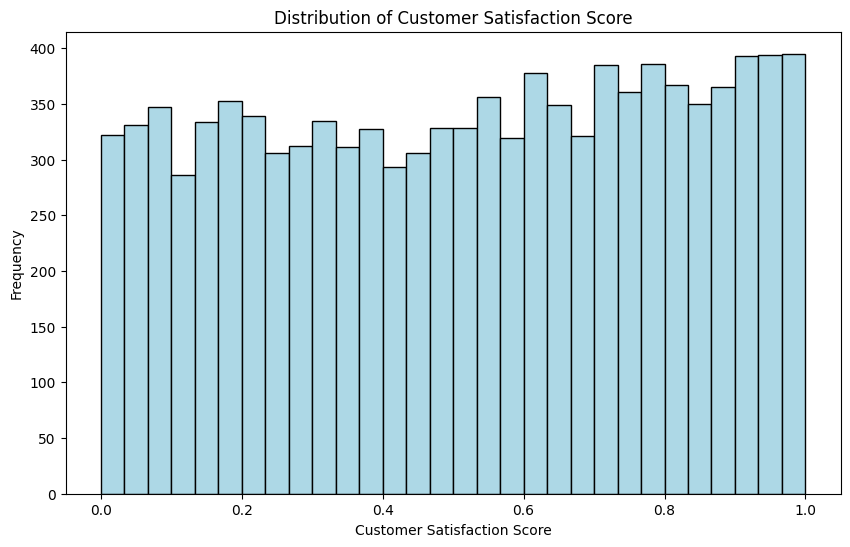

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['Customer Satisfication Score'], bins=30, color='lightblue', edgecolor='black')
plt.title('Distribution of Customer Satisfaction Score')
plt.xlabel('Customer Satisfaction Score')
plt.ylabel('Frequency')
plt.show()

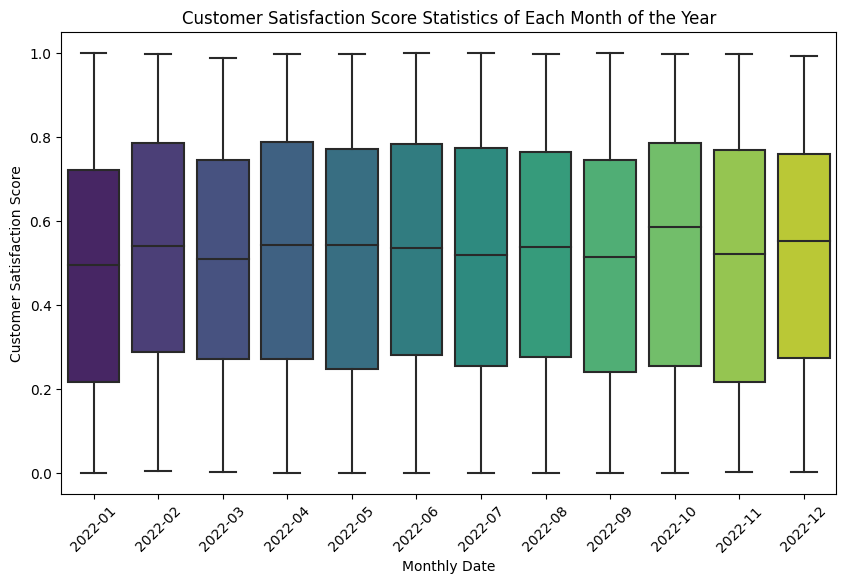

In [ ]:
# Ensure 'MonthYear' is a Categorical type with the correct order
order = df['MonthYear'].sort_values().unique()
df['MonthYear'] = df['MonthYear'].astype(CategoricalDtype(categories=order, ordered=True))

# Box plot to show the relationship between open date and the customer satisfaction
plt.figure(figsize=(10, 6))
sns.boxplot(x='MonthYear', y='Customer Satisfication Score', data=df, palette='viridis')
plt.title('Customer Satisfaction Score Statistics of Each Month of the Year')
plt.xlabel('Monthly Date')
plt.ylabel('Customer Satisfaction Score')
plt.xticks(rotation=45)
plt.show()


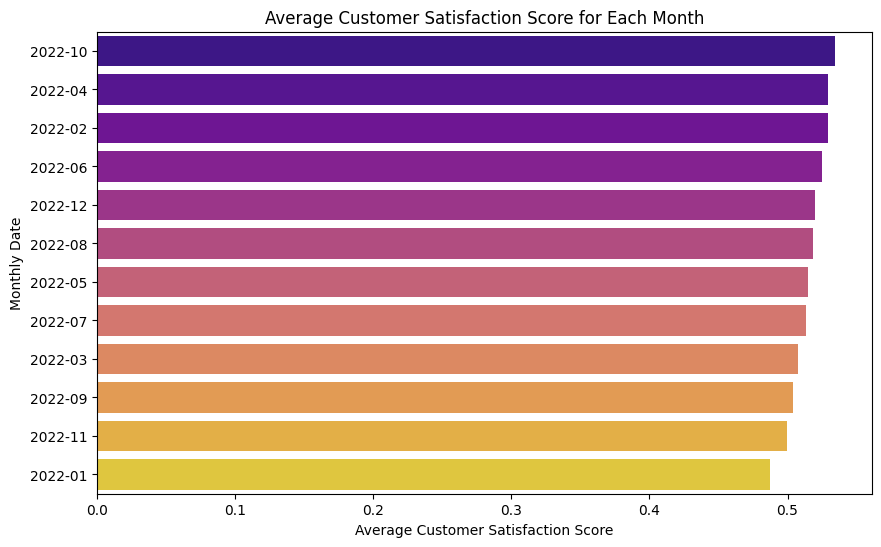

In [ ]:
# Calculate mean satisfaction score for each month
mean_values = df.groupby('MonthYear')['Customer Satisfication Score'].mean().reset_index()

# Sort DataFrame by mean satisfaction score in descending order
mean_values_sorted = mean_values.sort_values(by='Customer Satisfication Score', ascending=False)

# Horizontal bar plot to compare mean satisfaction score for each month
plt.figure(figsize=(10, 6))
sns.barplot(x='Customer Satisfication Score', y='MonthYear', data=mean_values_sorted, palette='plasma', order=mean_values_sorted['MonthYear'])
plt.title('Average Customer Satisfaction Score for Each Month')
plt.xlabel('Average Customer Satisfaction Score')
plt.ylabel('Monthly Date')
plt.show()


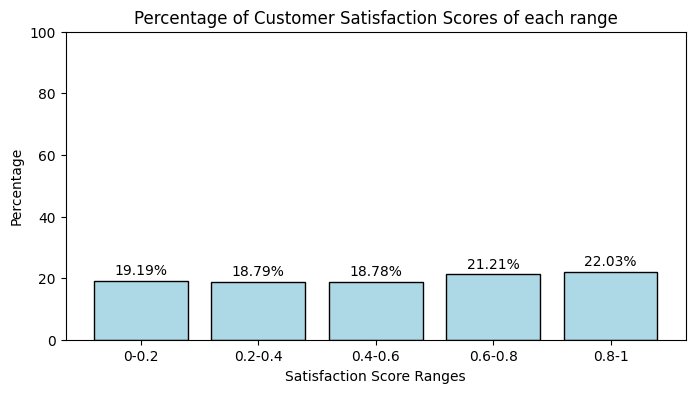

In [ ]:
# Define the score ranges
score_ranges = [(0.0000, 0.2000), (0.20001, 0.4000), (0.40001, 0.6000), (0.60001, 0.8000), (0.80001, 1.0)]

# Initialize lists to store data for plotting
range_labels = []
percentage_values = []

# Calculate the percentage for each range
for start, end in score_ranges:
    subset_data = df[(df['Customer Satisfication Score'] >= start) & (df['Customer Satisfication Score'] <= end)]
    percentage_within_range = (subset_data.shape[0] / df.shape[0]) * 100
    range_labels.append(f'{start:.2g}-{end:.2g}')  # Use .2g to format without trailing zeros
    percentage_values.append(percentage_within_range)

# Plot the bar chart
plt.figure(figsize=(8, 4))
plt.bar(range_labels, percentage_values, color='lightblue', edgecolor='black')
plt.title('Percentage of Customer Satisfaction Scores of each range')
plt.xlabel('Satisfaction Score Ranges')
plt.ylabel('Percentage')
plt.ylim(0, 100)  # Set y-axis limit to 100 for percentage

# Display the values on top of the bars
for i, value in enumerate(percentage_values):
    plt.text(i, value + 1, f'{value:.2f}%', ha='center', va='bottom')

plt.show()

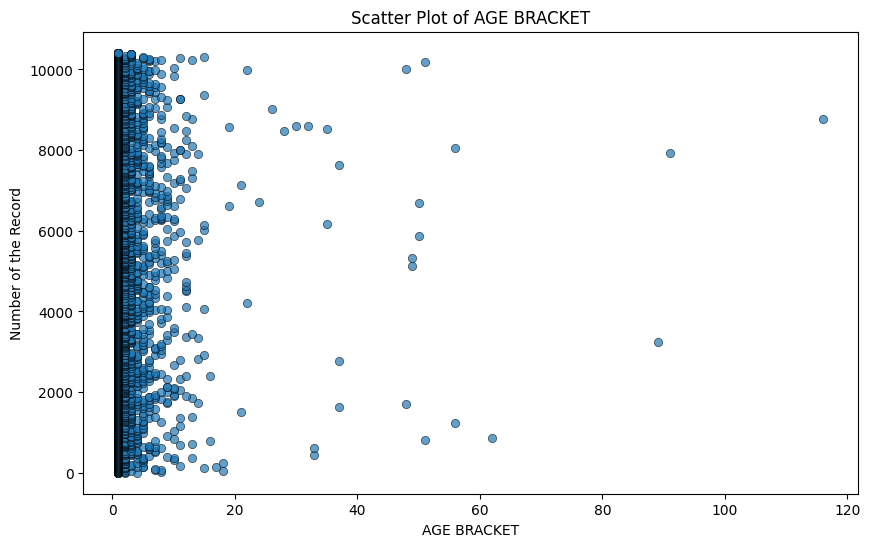

In [ ]:
# Create a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='AGE_BRACKET', y=df.index, data=df, edgecolor='black', alpha=0.7)
plt.title('Scatter Plot of AGE BRACKET')
plt.xlabel('AGE BRACKET')
plt.ylabel('Number of the Record')
plt.show()

<Figure size 1400x800 with 0 Axes>

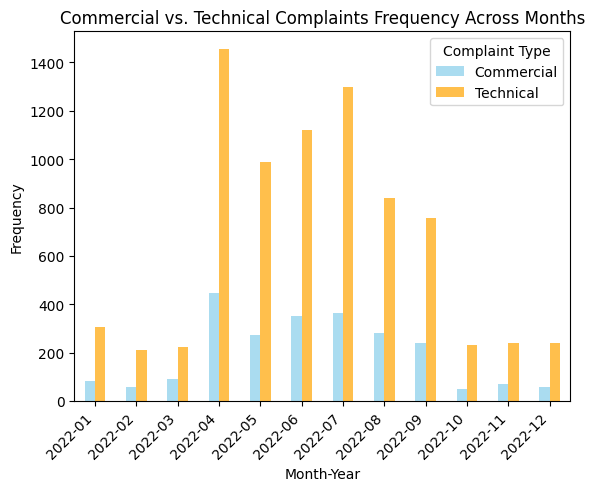

In [ ]:
df['MonthYear'] = df['OPEN_DATE'].dt.to_period('M')

# Create a new DataFrame with counts for each complaint type in each month
complaints_by_month = df.groupby(['MonthYear', 'COMPLAINT_TYPE']).size().unstack(fill_value=0)

# Plot the bar chart
plt.figure(figsize=(14, 8))
complaints_by_month.plot(kind='bar', color=['skyblue', 'orange'], alpha=0.7)

plt.title('Commercial vs. Technical Complaints Frequency Across Months')
plt.xlabel('Month-Year')
plt.ylabel('Frequency')
plt.legend(title='Complaint Type', loc='upper right')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.show()

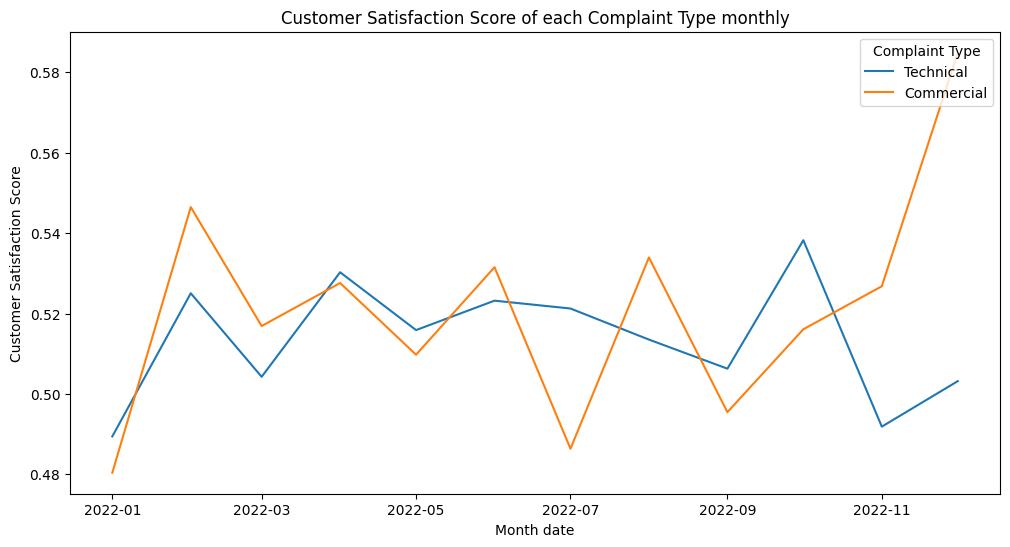

In [ ]:
df['MonthYear'] = pd.to_datetime(df['MonthYear'].astype(str))

plt.figure(figsize=(12, 6))
sns.lineplot(x='MonthYear', y='Customer Satisfication Score', hue='COMPLAINT_TYPE', data=df, errorbar=None)
plt.title('Customer Satisfaction Score of each Complaint Type monthly')
plt.xlabel('Month date')
plt.ylabel('Customer Satisfaction Score')
plt.legend(title='Complaint Type', loc='upper right')
plt.show()


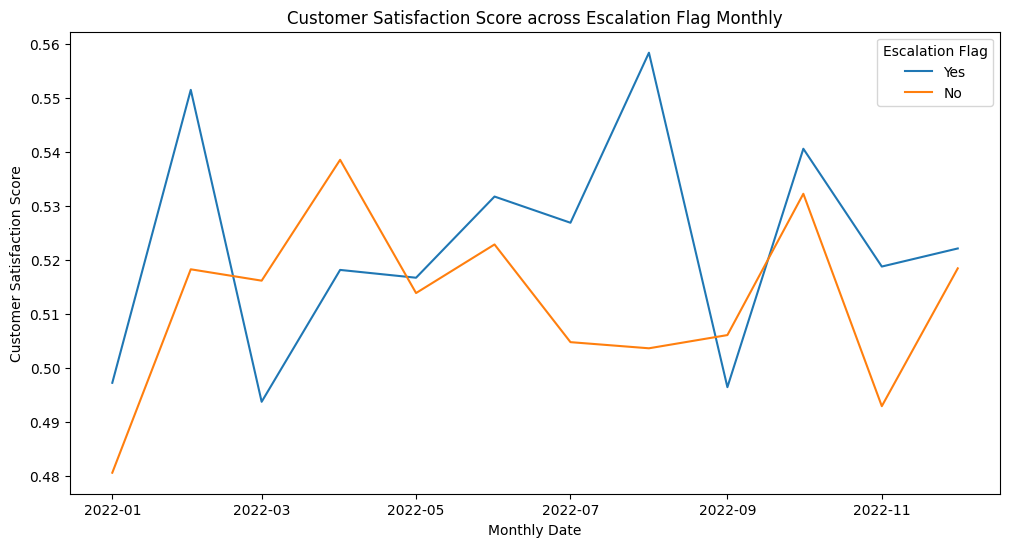

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='MonthYear', y='Customer Satisfication Score', hue='ESCALATION_FLAG', data=df, errorbar=None)
plt.title('Customer Satisfaction Score across Escalation Flag Monthly')
plt.xlabel('Monthly Date')
plt.ylabel('Customer Satisfaction Score')
plt.legend(title='Escalation Flag', loc='upper right')
plt.show()


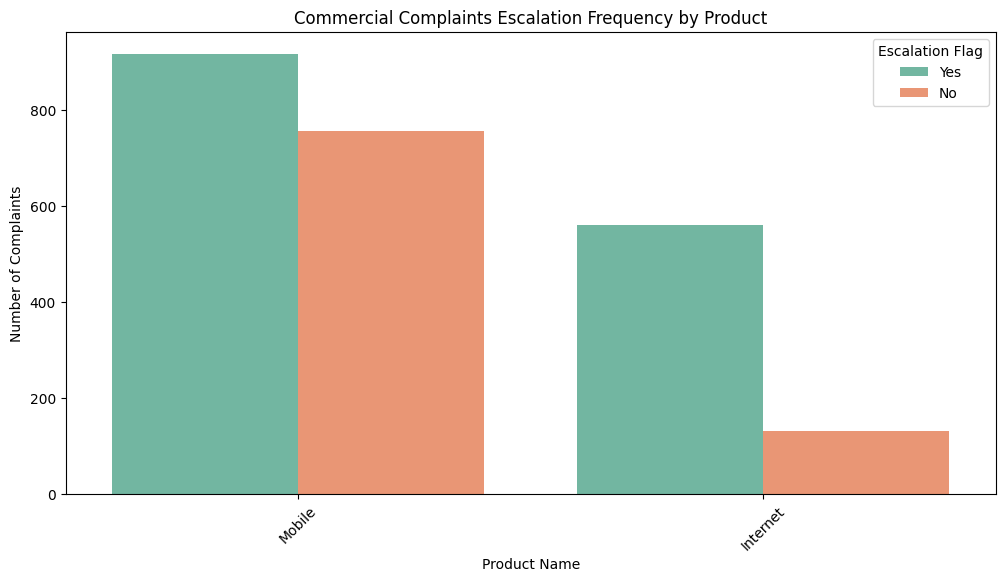

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='PRODUCT', hue='ESCALATION_FLAG', data=df[df['COMPLAINT_TYPE'] == 'Commercial'], palette='Set2')
plt.title('Commercial Complaints Escalation Frequency by Product')
plt.xlabel('Product Name')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.legend(title='Escalation Flag')
plt.show()


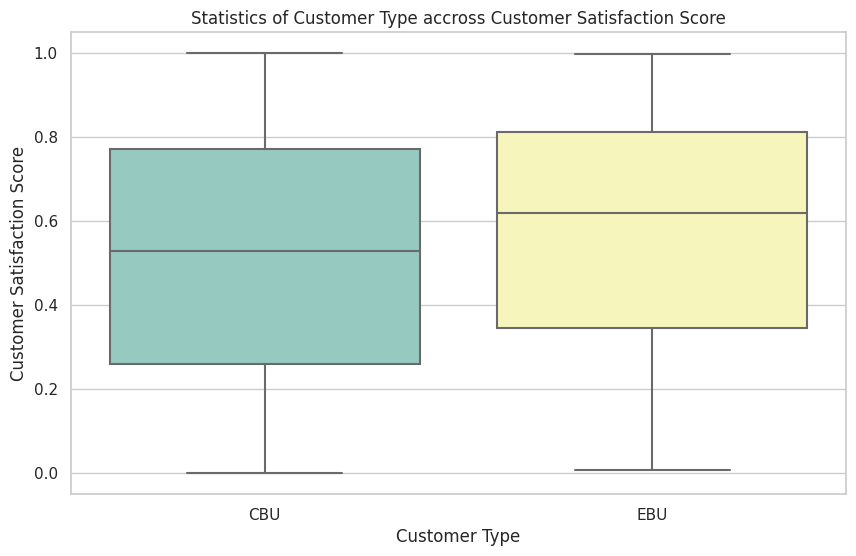

In [ ]:
# Set the style of the visualization
sns.set(style="whitegrid")

# Create a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='CUSTOMER_TYPE', y='Customer Satisfication Score', data=df, palette='Set3')
plt.title('Statistics of Customer Type accross Customer Satisfaction Score')
plt.xlabel('Customer Type')
plt.ylabel('Customer Satisfaction Score')
plt.show()

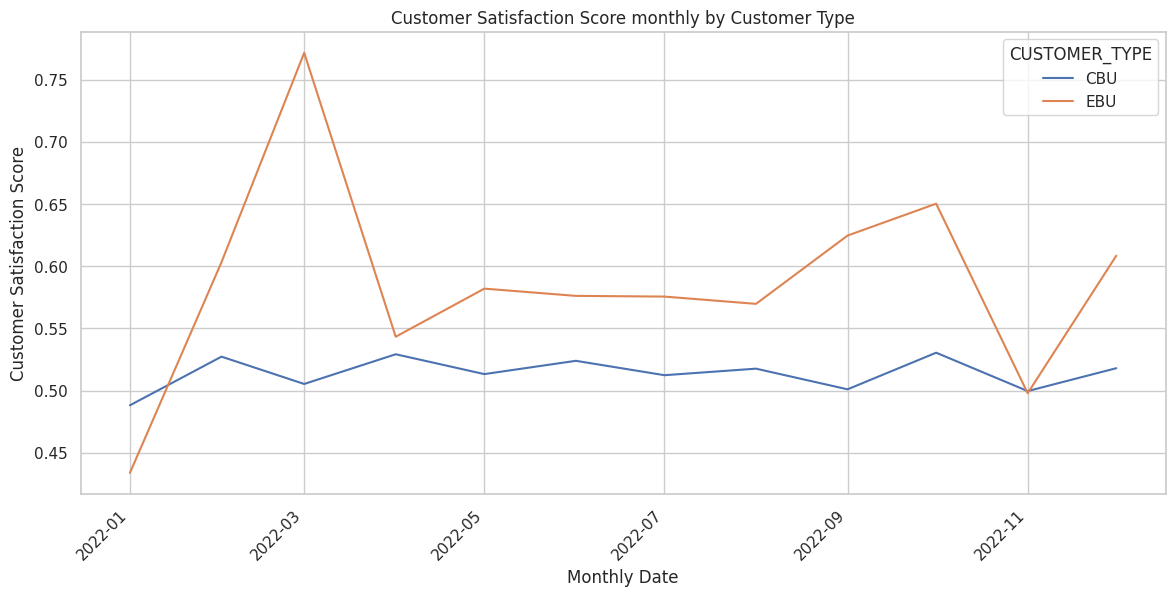

In [ ]:
sns.set(style="whitegrid")

# Create a line plot
plt.figure(figsize=(14, 6))
sns.lineplot(x='MonthYear', y='Customer Satisfication Score', hue='CUSTOMER_TYPE', data=df, errorbar=None)
plt.title('Customer Satisfaction Score monthly by Customer Type')
plt.xlabel('Monthly Date')
plt.ylabel('Customer Satisfaction Score')
plt.xticks(rotation=45, ha='right')
plt.show()

# Encoding& Heatmap


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Define the categorical columns to be encoded
categorical_columns = ['OFFER_NAME', 'CUSTOMER_TYPE', 'CUSTOMER_GROUP', 'CURRENT_STATUS', 'ESCALATION_FLAG',
                        'OPEN_USER', 'CLOSE_GROUP', 'CLOSE_USER', 'ACTUAL_COMPLAINT', 'OPEN_GR',
                        'COMPLAINT_TYPE', 'PRODUCT', 'CASE', 'OPEN_DATE', 'CLOSE_DATE']

# Create a dictionary to store encoders
label_encoders = {}

# Iterate through each categorical column and encode
for column in categorical_columns:
    le = LabelEncoder()
    df[column + '_ENCODED'] = le.fit_transform(df[column])
    label_encoders[column] = le  # Store the encoder in the dictionary for potential later use

# Display the first few rows of the encoded DataFrame
df.head()


,CASE_ID,OFFER_NAME,CUSTOMER_TYPE,CUSTOMER_GROUP,CURRENT_STATUS,ESCALATION_FLAG,OPEN_DATE,OPEN_USER,CLOSE_DATE,CLOSE_GROUP,...,OPEN_USER_ENCODED,CLOSE_GROUP_ENCODED,CLOSE_USER_ENCODED,ACTUAL_COMPLAINT_ENCODED,OPEN_GR_ENCODED,COMPLAINT_TYPE_ENCODED,PRODUCT_ENCODED,CASE_ENCODED,OPEN_DATE_ENCODED,CLOSE_DATE_ENCODED
0,CAS-1060890-L3D6Q6,FTTH Home,CBU,FTTH Home,Resolved,Yes,2022-06-19 06:07:00,DANA,2022-06-21 13:41:00,F&I_BO,...,55,19,57,0,10,1,0,4,4678,4849
1,CAS-388567-W4B9Q3,Bitstream Home,CBU,FTTH Home,Resolved,Yes,2022-04-04 14:11:00,TCRMService,2022-05-04 12:13:00,Mobile_BO,...,247,28,78,1,17,0,1,0,961,2741
2,CAS-1494939-L9F0X7,Bitstream Home,CBU,Wanadoo-ADSL-Res,Resolved,No,2022-03-08 03:20:00,MOUTAZ,2022-03-08 03:20:00,CYC_COMMERCAIL_TEAM,...,165,10,165,2,2,1,0,4,860,852
3,CAS-1059985-K3Y9F7,FTTH Home,CBU,FTTH Home,Resolved,No,2022-06-18 20:38:00,MOATH,2022-06-18 20:38:00,Unknown,...,154,46,152,2,18,1,0,4,4671,4694
4,CAS-1239942-Y1S2F5,FTTH Home,CBU,FTTH Home,Resolved,No,2022-06-07 01:22:00,IBRAHIM,2022-06-07 01:22:00,CYC_COMMERCAIL_TEAM,...,110,10,108,2,2,1,0,4,4118,4135


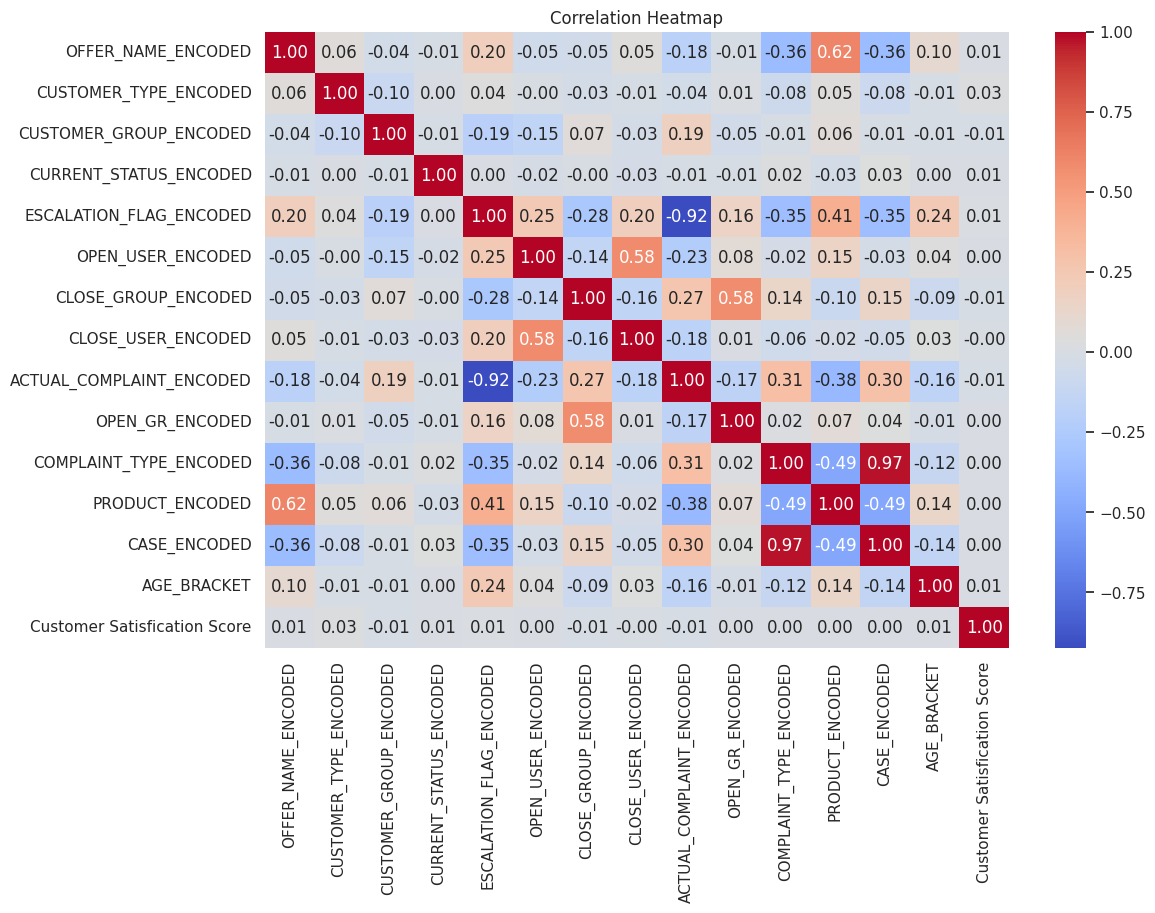

In [ ]:

# Select columns for the heatmap
selected_columns = ['OFFER_NAME_ENCODED', 'CUSTOMER_TYPE_ENCODED', 'CUSTOMER_GROUP_ENCODED',
                    'CURRENT_STATUS_ENCODED', 'ESCALATION_FLAG_ENCODED', 'OPEN_USER_ENCODED',
                    'CLOSE_GROUP_ENCODED', 'CLOSE_USER_ENCODED', 'ACTUAL_COMPLAINT_ENCODED',
                    'OPEN_GR_ENCODED', 'COMPLAINT_TYPE_ENCODED', 'PRODUCT_ENCODED', 'CASE_ENCODED',
                    'AGE_BRACKET', 'Customer Satisfication Score']

# Create a DataFrame with selected columns
heatmap_data = df[selected_columns]

# Calculate the correlation matrix
correlation_matrix = heatmap_data.corr()

# Create a heatmap using Seaborn
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


In [ ]:
df.corr()

<ipython-input-57-2f6f6606aa2c>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,AGE_BRACKET,Customer Satisfication Score,OFFER_NAME_ENCODED,CUSTOMER_TYPE_ENCODED,CUSTOMER_GROUP_ENCODED,CURRENT_STATUS_ENCODED,ESCALATION_FLAG_ENCODED,OPEN_USER_ENCODED,CLOSE_GROUP_ENCODED,CLOSE_USER_ENCODED,ACTUAL_COMPLAINT_ENCODED,OPEN_GR_ENCODED,COMPLAINT_TYPE_ENCODED,PRODUCT_ENCODED,CASE_ENCODED,OPEN_DATE_ENCODED,CLOSE_DATE_ENCODED
AGE_BRACKET,1.000000,0.005236,0.101883,-0.007900,-0.012895,0.003313,0.241773,0.041832,-0.086086,0.033282,-0.161656,-0.014910,-0.118695,0.139026,-0.142748,-0.016206,0.012167
Customer Satisfication Score,0.005236,1.000000,0.005573,0.028814,-0.011494,0.007421,0.013117,0.000381,-0.013142,-0.002340,-0.013549,0.002384,0.001176,0.003186,0.001969,-0.005375,-0.008284
OFFER_NAME_ENCODED,0.101883,0.005573,1.000000,0.057385,-0.044405,-0.012687,0.196229,-0.054186,-0.047663,0.048553,-0.184485,-0.013223,-0.363743,0.616001,-0.361322,0.009619,0.021399
CUSTOMER_TYPE_ENCODED,-0.007900,0.028814,0.057385,1.000000,-0.100406,0.002918,0.038476,-0.002747,-0.031929,-0.008300,-0.042340,0.012692,-0.080594,0.050352,-0.084645,-0.004282,-0.003715
CUSTOMER_GROUP_ENCODED,-0.012895,-0.011494,-0.044405,-0.100406,1.000000,-0.012158,-0.193955,-0.152730,0.065160,-0.030927,0.187771,-0.045478,-0.012146,0.064562,-0.012163,0.062832,0.076029
CURRENT_STATUS_ENCODED,0.003313,0.007421,-0.012687,0.002918,-0.012158,1.000000,0.003109,-0.017920,-0.001684,-0.029185,-0.012658,-0.013125,0.024396,-0.030234,0.031750,-0.005217,-0.005449
ESCALATION_FLAG_ENCODED,0.241773,0.013117,0.196229,0.038476,-0.193955,0.003109,1.000000,0.245283,-0.277237,0.198292,-0.924268,0.158927,-0.351610,0.412170,-0.347462,-0.081580,-0.091530
OPEN_USER_ENCODED,0.041832,0.000381,-0.054186,-0.002747,-0.152730,-0.017920,0.245283,1.000000,-0.135265,0.579594,-0.229460,0.082199,-0.023704,0.150895,-0.032705,-0.076286,-0.091816
CLOSE_GROUP_ENCODED,-0.086086,-0.013142,-0.047663,-0.031929,0.065160,-0.001684,-0.277237,-0.135265,1.000000,-0.155946,0.267201,0.577366,0.139619,-0.096132,0.147469,0.151948,0.147257
CLOSE_USER_ENCODED,0.033282,-0.002340,0.048553,-0.008300,-0.030927,-0.029185,0.198292,0.579594,-0.155946,1.000000,-0.176299,0.007627,-0.057968,-0.023182,-0.052251,-0.028035,-0.022731


In [ ]:
df.drop(['OFFER_NAME_ENCODED', 'CUSTOMER_TYPE_ENCODED', 'CUSTOMER_GROUP_ENCODED',
                    'CURRENT_STATUS_ENCODED', 'ESCALATION_FLAG_ENCODED', 'OPEN_USER_ENCODED',
                    'CLOSE_GROUP_ENCODED', 'CLOSE_USER_ENCODED', 'ACTUAL_COMPLAINT_ENCODED',
                    'OPEN_GR_ENCODED', 'COMPLAINT_TYPE_ENCODED', 'PRODUCT_ENCODED', 'CASE_ENCODED',],axis=1,inplace=True)

# Outliers Detection

In [ ]:
# IQR method to chick for outliers
q1 = df['Customer Satisfication Score'].quantile(0.25)
q3 = df['Customer Satisfication Score'].quantile(0.75)
iqr = q3 - q1
df['outlier_iqr'] = ((df['Customer Satisfication Score'] < (q1 - 1.5 * iqr)) | (df['Customer Satisfication Score'] > (q3 + 1.5 * iqr)))

outliers_iqr = df[df['outlier_iqr'] == True]
outliers_iqr

,CASE_ID,OFFER_NAME,CUSTOMER_TYPE,CUSTOMER_GROUP,CURRENT_STATUS,ESCALATION_FLAG,OPEN_DATE,OPEN_USER,CLOSE_DATE,CLOSE_GROUP,...,ACTUAL_COMPLAINT,OPEN_GR,COMPLAINT_TYPE,PRODUCT,CASE,Customer Satisfication Score,MonthYear,OPEN_DATE_ENCODED,CLOSE_DATE_ENCODED,outlier_iqr


In [ ]:
# IQR method to chick for outliers
q1 = df['AGE_BRACKET'].quantile(0.25)
q3 = df['AGE_BRACKET'].quantile(0.75)
iqr = q3 - q1
df['outlier_iqr'] = ((df['AGE_BRACKET'] < (q1 - 1.5 * iqr)) | (df['Customer Satisfication Score'] > (q3 + 1.5 * iqr)))

outliers_iqr = df[df['outlier_iqr'] == True]
outliers_iqr

,CASE_ID,OFFER_NAME,CUSTOMER_TYPE,CUSTOMER_GROUP,CURRENT_STATUS,ESCALATION_FLAG,OPEN_DATE,OPEN_USER,CLOSE_DATE,CLOSE_GROUP,...,ACTUAL_COMPLAINT,OPEN_GR,COMPLAINT_TYPE,PRODUCT,CASE,Customer Satisfication Score,MonthYear,OPEN_DATE_ENCODED,CLOSE_DATE_ENCODED,outlier_iqr
